
Feature Importance:

          Feature  Importance
8        cpu_lag1    0.444771
3      cpu_change    0.319433
5      net_change    0.128067
10       net_lag1    0.040141
9        ram_lag1    0.034307
1   ram_roll_mean    0.009107
2   net_roll_mean    0.006841
0   cpu_roll_mean    0.006223
4      ram_change    0.004283
7          minute    0.004151
6            hour    0.002678


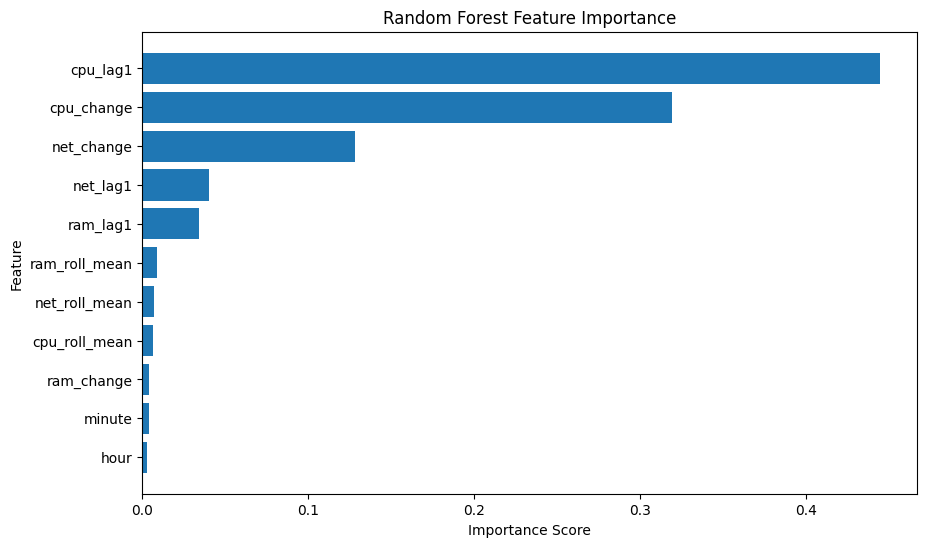

Random Forest Results
MSE: 2.0227749838423246
Train MSE:  0.3016799212675264
RMSE: 1.4222429412172608
R²: 0.8992620252232234


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# -----------------------------
# 1 Load Train and Test Data
# -----------------------------
train_data = pd.read_csv("../data/train_data.csv")
test_data = pd.read_csv("../data/test_data.csv")

# -----------------------------
# 2 Define Target Variables
# -----------------------------
targets = ["cpu_percent", "ram_percent", "net_bytes_per_sec"]

X_train = train_data.drop(columns=targets)
joblib.dump(X_train.columns, "../data/column.pkl")
y_train = train_data[targets]

X_test = test_data.drop(columns=targets)
y_test = test_data[targets]

# -----------------------------
# 3 Train Random Forest Model
# -----------------------------
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

#Model Dumping
joblib.dump(rf_model, "../data/model.pkl")

# -----------------------------
# 4 Predictions
# -----------------------------
y_pred = rf_model.predict(X_test)
x_pred = rf_model.predict(X_train)
residuals = np.abs(x_pred - y_train.values)
normalized_residuals = residuals / (np.abs(y_train.values) + 1e-6)
scores = np.linalg.norm(normalized_residuals, axis=1)
threshold = np.percentile(scores, 97)

#Threshold Dumping
joblib.dump(threshold, "../data/threshold.pkl")


# -----------------------------
# 5 Evaluation Metrics
# -----------------------------
mse = mean_squared_error(y_test, y_pred)
x_mse = mean_squared_error(y_train, x_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)



# ----------------------------------
# 1 Get Feature Importance
# ----------------------------------
importance = rf_model.feature_importances_

# ----------------------------------
# 2 Create DataFrame
# ----------------------------------
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
})

# ----------------------------------
# 3 Sort by Importance
# ----------------------------------
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# ----------------------------------
# 4 Print Important Features
# ----------------------------------
print("\nFeature Importance:\n")
print(feature_importance)

# ----------------------------------
# 5 Plot Feature Importance
# ----------------------------------
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()


print("Random Forest Results")
print("MSE:", mse)
print("Train MSE: ", x_mse)
print("RMSE:", rmse)
print("R²:", r2)